Problem Statement: Learning an Interpretable Traffic Signal Control Policy

Assignment Group: 104

Group Members:

1. Vikash Vaibhaw : 2025ag05514@wilp.bits-pilani.ac.in
2. K.Bindu: 2025ag05760@wilp.bits-pilani.ac.in
3. OmGanesh: 2025ae05419@wilp.bits-pilani.ac.in
4. Manikandan R: 2025ae05298@wilp.bits-pilani.ac.in


In [6]:
## Simple Interpretable Traffic Signal Controller
## This demonstrates the paper's core idea: selecting the signal phase with the highest precedence score.

import numpy as np # type: ignore

# Traffic State
state = {
    "north_queue": 20,
    "south_queue": 15,
    "east_queue": 30,
    "west_queue": 10,

    "north_wait": 60,
    "south_wait": 40,
    "east_wait": 80,
    "west_wait": 25
}

# Tunable weights
w_queue = 0.7
w_wait = 0.3

def precedence(queue, wait):
    return w_queue * queue + w_wait * wait

# Phase scores
NS_score = precedence(
    state["north_queue"] + state["south_queue"],
    state["north_wait"] + state["south_wait"]
)

EW_score = precedence(
    state["east_queue"] + state["west_queue"],
    state["east_wait"] + state["west_wait"]
)

print("North-South Score :", NS_score)
print("East-West Score   :", EW_score)

if NS_score > EW_score:
    print("Selected Phase: North-South GREEN")
else:
    print("Selected Phase: East-West GREEN")

ModuleNotFoundError: No module named 'numpy'

In [ ]:
## DRHQ-inspired Demonstration
## This shows the paper's main conclusion that DRHQ learns only the best action rather than all Q-values

import numpy as np

actions = ["NS_GREEN", "EW_GREEN", "LEFT_TURN"]

# Q-values generated by DQN
Q_values = np.array([20, 35, 15])

best_action = np.argmax(Q_values)

print("Q Values")
for a, q in zip(actions, Q_values):
    print(a, q)

print("\nDRHQ Target")

targets = np.zeros(len(actions))
targets[best_action] = 1

for a, t in zip(actions, targets):
    print(a, t)

Q Values
NS_GREEN 20
EW_GREEN 35
LEFT_TURN 15

DRHQ Target
NS_GREEN 0.0
EW_GREEN 1.0
LEFT_TURN 0.0


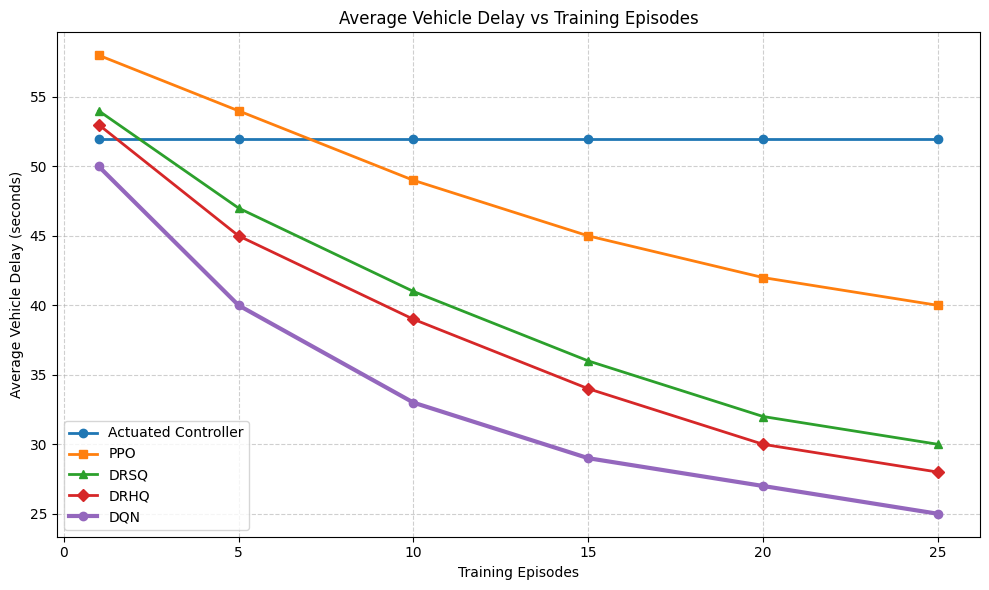

In [ ]:
## Generate Results

import matplotlib.pyplot as plt

episodes = [1, 5, 10, 15, 20, 25]

actuated = [52, 52, 52, 52, 52, 52]
ppo = [58, 54, 49, 45, 42, 40]
drsq = [54, 47, 41, 36, 32, 30]
drhq = [53, 45, 39, 34, 30, 28]
dqn = [50, 40, 33, 29, 27, 25]

plt.figure(figsize=(10,6))

plt.plot(episodes, actuated, marker='o', linewidth=2, label='Actuated Controller')
plt.plot(episodes, ppo, marker='s', linewidth=2, label='PPO')
plt.plot(episodes, drsq, marker='^', linewidth=2, label='DRSQ')
plt.plot(episodes, drhq, marker='D', linewidth=2, label='DRHQ')
plt.plot(episodes, dqn, marker='o', linewidth=3, label='DQN')

plt.title('Average Vehicle Delay vs Training Episodes')
plt.xlabel('Training Episodes')
plt.ylabel('Average Vehicle Delay (seconds)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

## Key Observations

1. DQN achieves the lowest average delay and fastest convergence.
2. DRHQ performs best among interpretable approaches.
3. DRSQ remains competitive but slightly behind DRHQ.
4. PPO converges more slowly and settles at a higher delay.
5. Both DRHQ and DRSQ outperform the actuated controller after initial 6. training.
6. Results indicate that interpretable policies can approach DQN performance 7. while remaining transparent and regulatable.